# EDA Analysis � Bluestock MF Capstone

Exploratory analysis across NAV, AUM, SIP, performance, portfolio, and investor data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

engine = create_engine('sqlite:///../db/bluestock_mf.db')
print("Connected to database.")

Connected to database.


## 1. NAV Trends

NAV movement over time for a sample of funds.

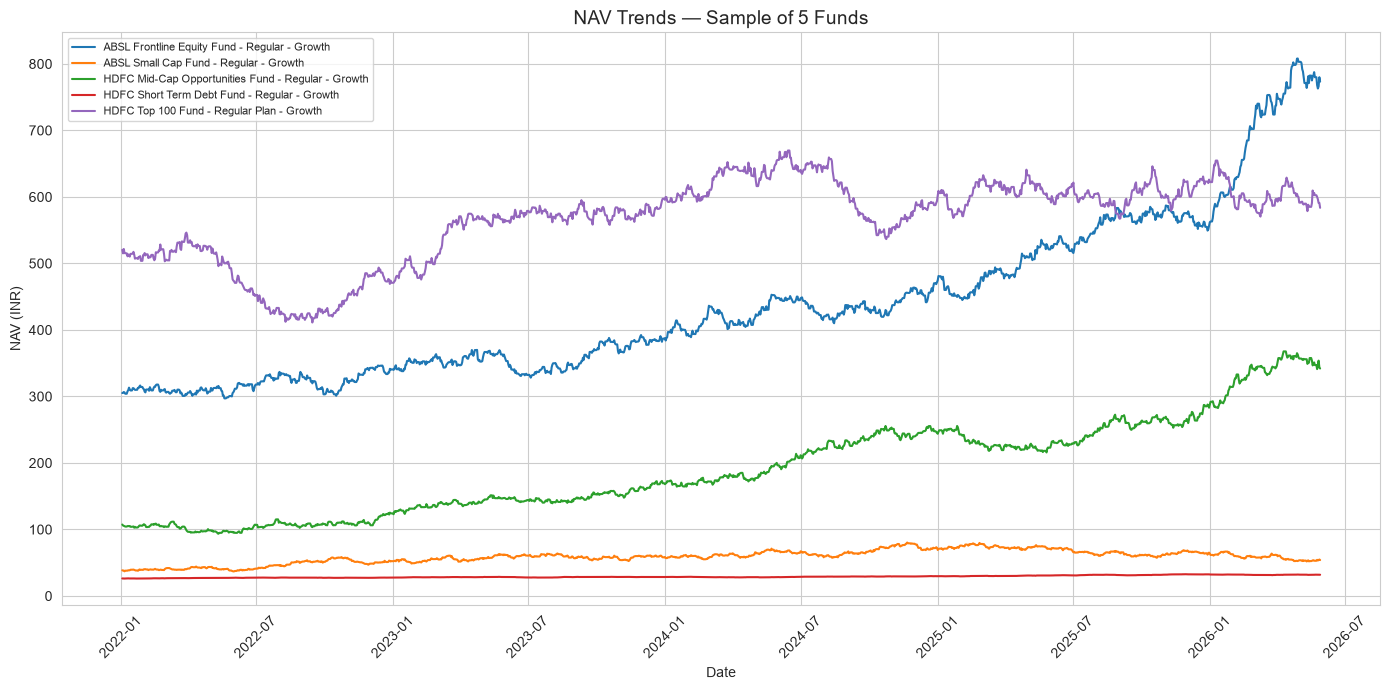

In [2]:
query = '''
SELECT f.scheme_name, d.date, n.nav
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
JOIN dim_date d ON n.date_id = d.date_id
WHERE f.amfi_code IN (SELECT amfi_code FROM dim_fund LIMIT 5)
ORDER BY d.date
'''
nav_df = pd.read_sql(query, engine)
nav_df['date'] = pd.to_datetime(nav_df['date'])

fig, ax = plt.subplots(figsize=(14, 7))
for name, group in nav_df.groupby('scheme_name'):
    ax.plot(group['date'], group['nav'], label=name)

ax.set_title('NAV Trends — Sample of 5 Funds', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('NAV (INR)')
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. AUM Growth by Fund House

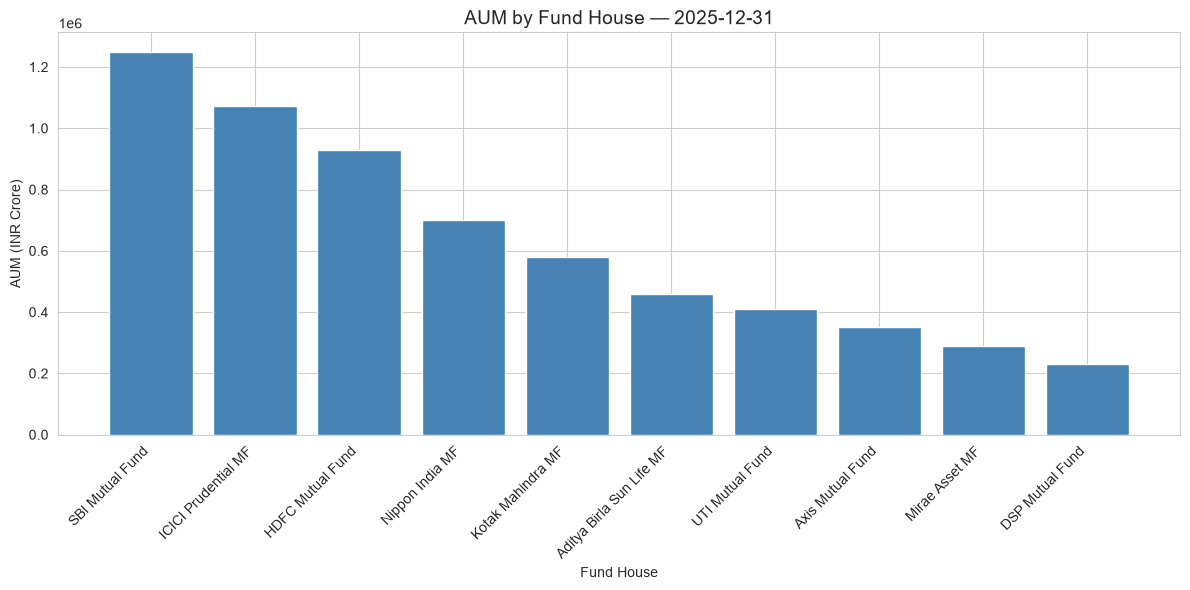

In [3]:
aum_query = '''
SELECT fund_house, date, aum_crore
FROM fact_aum
ORDER BY date
'''
aum_df = pd.read_sql(aum_query, engine)
aum_df['date'] = pd.to_datetime(aum_df['date'])

latest_date = aum_df['date'].max()
latest_aum = aum_df[aum_df['date'] == latest_date].sort_values('aum_crore', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(latest_aum['fund_house'], latest_aum['aum_crore'], color='steelblue')
ax.set_title(f'AUM by Fund House — {latest_date.date()}', fontsize=14)
ax.set_xlabel('Fund House')
ax.set_ylabel('AUM (INR Crore)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. SIP Inflow Time-Series

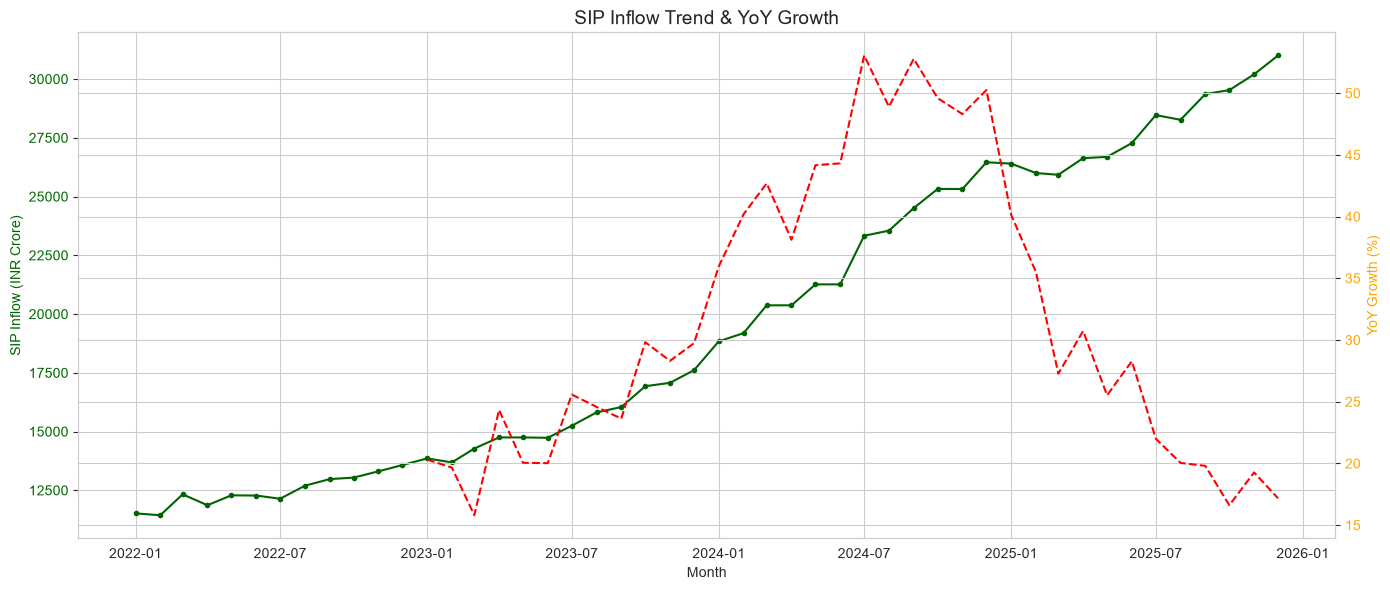

In [5]:
sip_query = '''
SELECT month, sip_inflow_crore, active_sip_accounts_crore, yoy_growth_pct
FROM fact_sip_industry
ORDER BY month
'''
sip_df = pd.read_sql(sip_query, engine)
sip_df['month'] = pd.to_datetime(sip_df['month'])

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(sip_df['month'], sip_df['sip_inflow_crore'], color='darkgreen', marker='o', markersize=3, label='SIP Inflow (Cr)')
ax1.set_xlabel('Month')
ax1.set_ylabel('SIP Inflow (INR Crore)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')

ax2 = ax1.twinx()
ax2.plot(sip_df['month'], sip_df['yoy_growth_pct'], color='Red', linestyle='--', label='YoY Growth %')
ax2.set_ylabel('YoY Growth (%)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('SIP Inflow Trend & YoY Growth', fontsize=14)
fig.tight_layout()
plt.xticks(rotation=45)
plt.show()

## 4. Category-wise Average Returns (Heatmap)

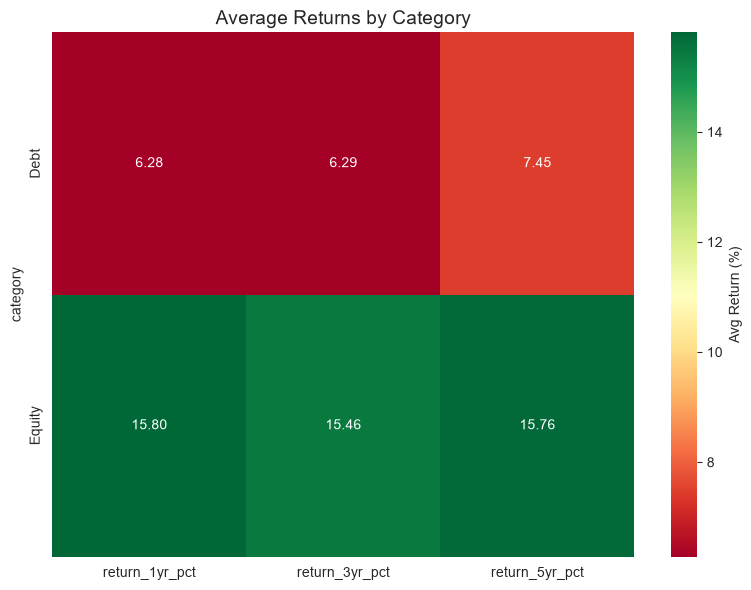

In [6]:
cat_query = '''
SELECT f.category, p.return_1yr_pct, p.return_3yr_pct, p.return_5yr_pct
FROM fact_performance p
JOIN dim_fund f ON p.amfi_code = f.amfi_code
'''
cat_df = pd.read_sql(cat_query, engine)

heatmap_data = cat_df.groupby('category')[['return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct']].mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Avg Return (%)'})
ax.set_title('Average Returns by Category', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Investor Demographics — Age & Gender

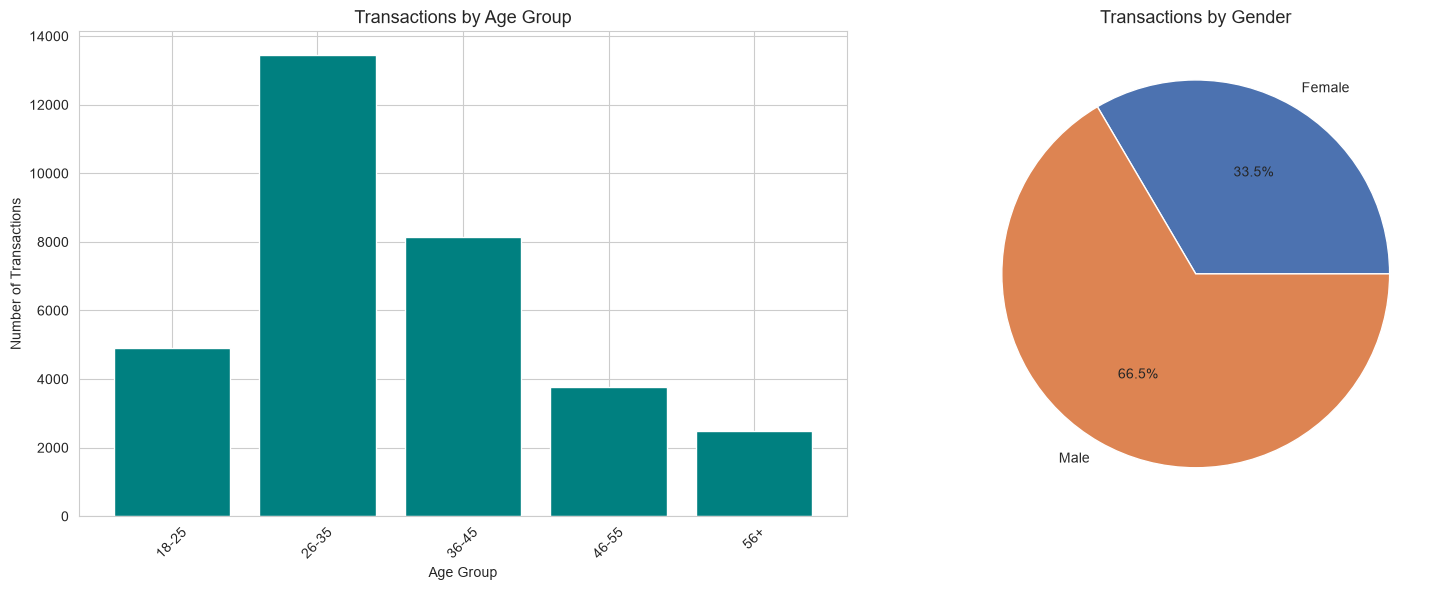

In [7]:
demo_query = '''
SELECT age_group, gender, COUNT(*) AS num_transactions, SUM(amount_inr) AS total_amount
FROM fact_transactions
GROUP BY age_group, gender
'''
demo_df = pd.read_sql(demo_query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

age_totals = demo_df.groupby('age_group')['num_transactions'].sum().sort_index()
axes[0].bar(age_totals.index, age_totals.values, color='teal')
axes[0].set_title('Transactions by Age Group', fontsize=13)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

gender_totals = demo_df.groupby('gender')['num_transactions'].sum()
axes[1].pie(gender_totals.values, labels=gender_totals.index, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Transactions by Gender', fontsize=13)

plt.tight_layout()
plt.show()

## 6. Geographic Distribution — Transactions by State

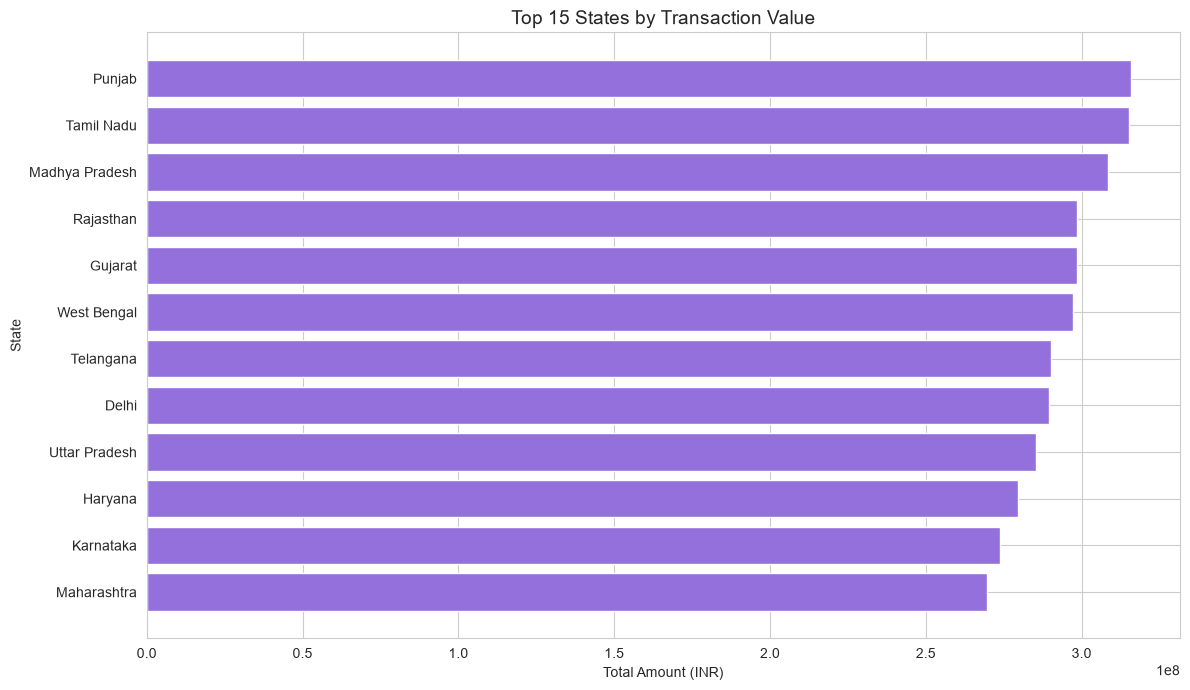

In [8]:
geo_query = '''
SELECT state, COUNT(*) AS num_transactions, SUM(amount_inr) AS total_amount
FROM fact_transactions
GROUP BY state
ORDER BY total_amount DESC
LIMIT 15
'''
geo_df = pd.read_sql(geo_query, engine)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(geo_df['state'][::-1], geo_df['total_amount'][::-1], color='mediumpurple')
ax.set_title('Top 15 States by Transaction Value', fontsize=14)
ax.set_xlabel('Total Amount (INR)')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

## 7. Folio Growth Over Time

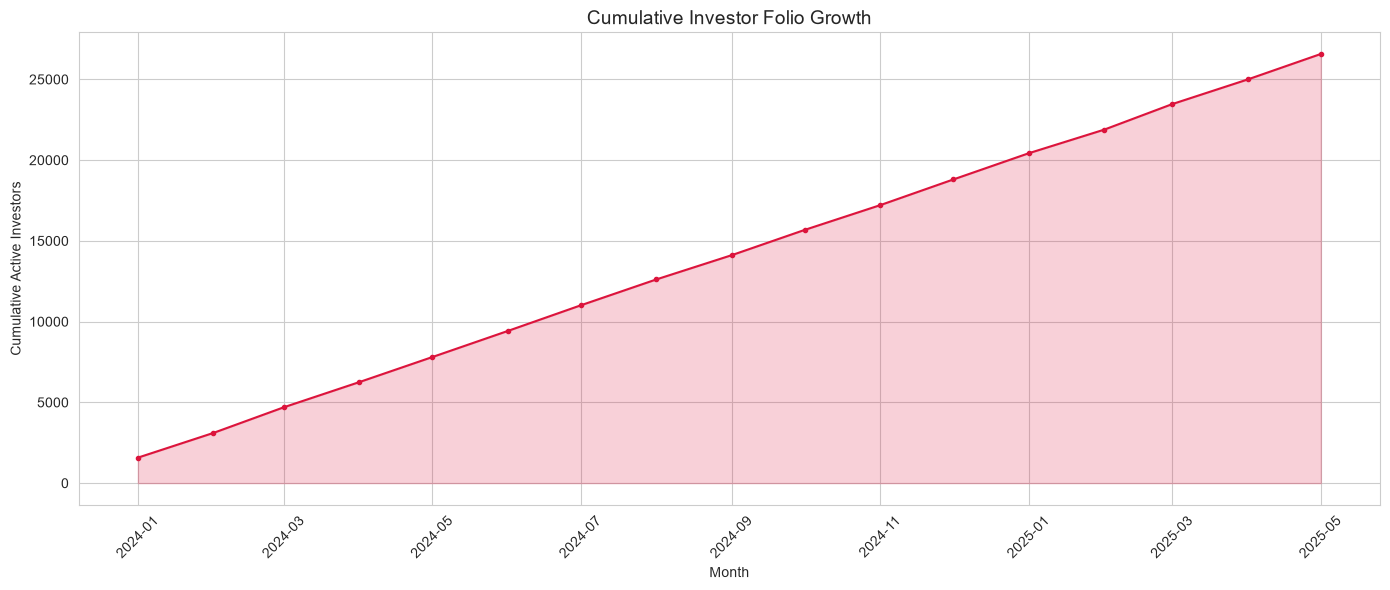

In [9]:
folio_query = '''
SELECT d.year, d.month, COUNT(DISTINCT t.investor_id) AS active_investors
FROM fact_transactions t
JOIN dim_date d ON t.date_id = d.date_id
GROUP BY d.year, d.month
ORDER BY d.year, d.month
'''
folio_df = pd.read_sql(folio_query, engine)
folio_df['period'] = pd.to_datetime(folio_df['year'].astype(str) + '-' + folio_df['month'].astype(str) + '-01')
folio_df['cumulative_investors'] = folio_df['active_investors'].cumsum()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(folio_df['period'], folio_df['cumulative_investors'], color='crimson', marker='o', markersize=3)
ax.fill_between(folio_df['period'], folio_df['cumulative_investors'], alpha=0.2, color='crimson')
ax.set_title('Cumulative Investor Folio Growth', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Active Investors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Correlation Matrix — Fund Performance Metrics

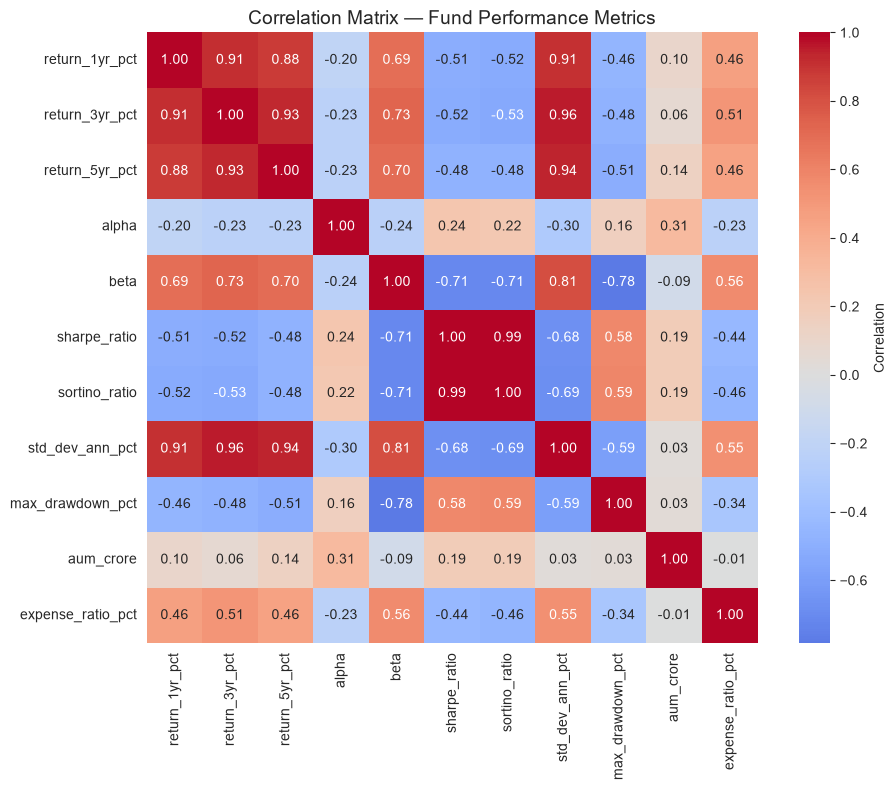

In [10]:
corr_query = '''
SELECT return_1yr_pct, return_3yr_pct, return_5yr_pct, alpha, beta,
       sharpe_ratio, sortino_ratio, std_dev_ann_pct, max_drawdown_pct,
       aum_crore, expense_ratio_pct
FROM fact_performance
'''
corr_df = pd.read_sql(corr_query, engine)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix — Fund Performance Metrics', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Sector Allocation Across Portfolios

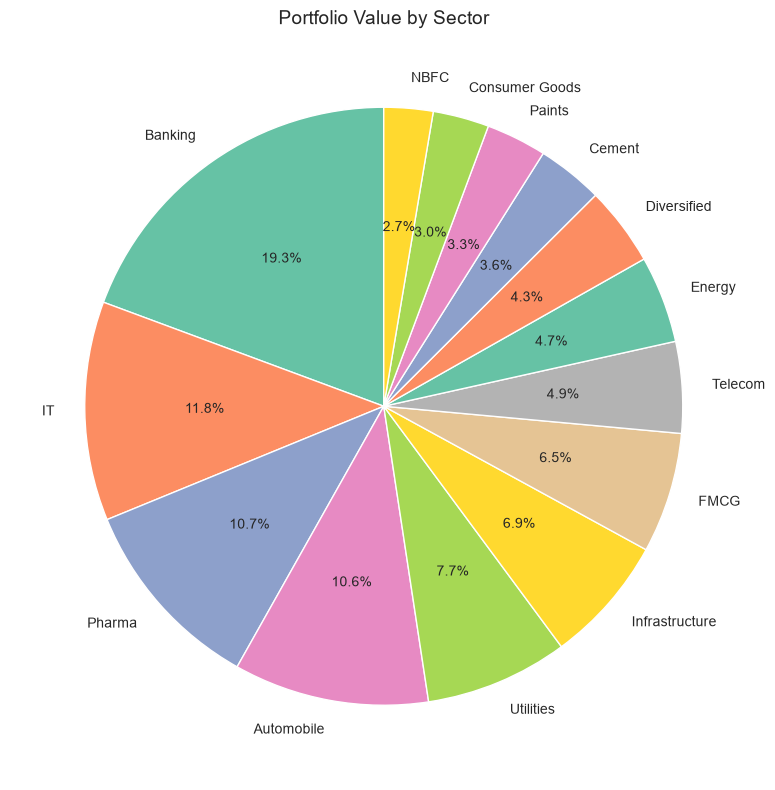

In [11]:
sector_query = '''
SELECT sector, SUM(market_value_cr) AS total_value
FROM fact_portfolio
GROUP BY sector
ORDER BY total_value DESC
'''
sector_df = pd.read_sql(sector_query, engine)

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('Set2', len(sector_df))
ax.pie(sector_df['total_value'], labels=sector_df['sector'], autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Portfolio Value by Sector', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Expense Ratio Distribution by Category

C:\Users\TEJ\AppData\Local\Temp\ipykernel_17824\1465419327.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=exp_df, x='category', y='expense_ratio_pct', ax=ax, palette='pastel')


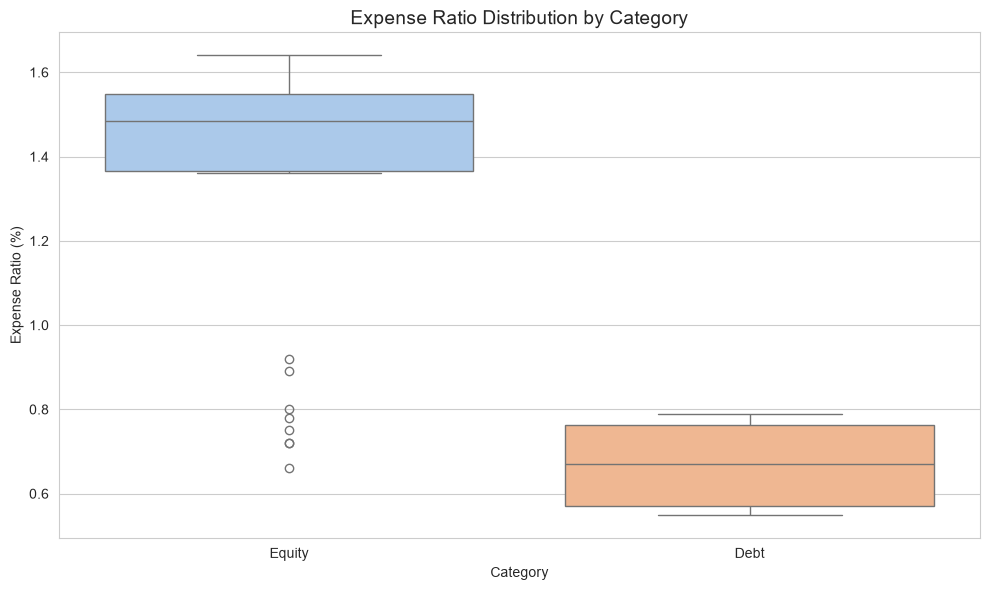

In [12]:
exp_query = '''
SELECT f.category, p.expense_ratio_pct
FROM fact_performance p
JOIN dim_fund f ON p.amfi_code = f.amfi_code
'''
exp_df = pd.read_sql(exp_query, engine)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=exp_df, x='category', y='expense_ratio_pct', ax=ax, palette='pastel')
ax.set_title('Expense Ratio Distribution by Category', fontsize=14)
ax.set_xlabel('Category')
ax.set_ylabel('Expense Ratio (%)')
plt.tight_layout()
plt.show()

## 11. Risk vs Return — Fund Positioning

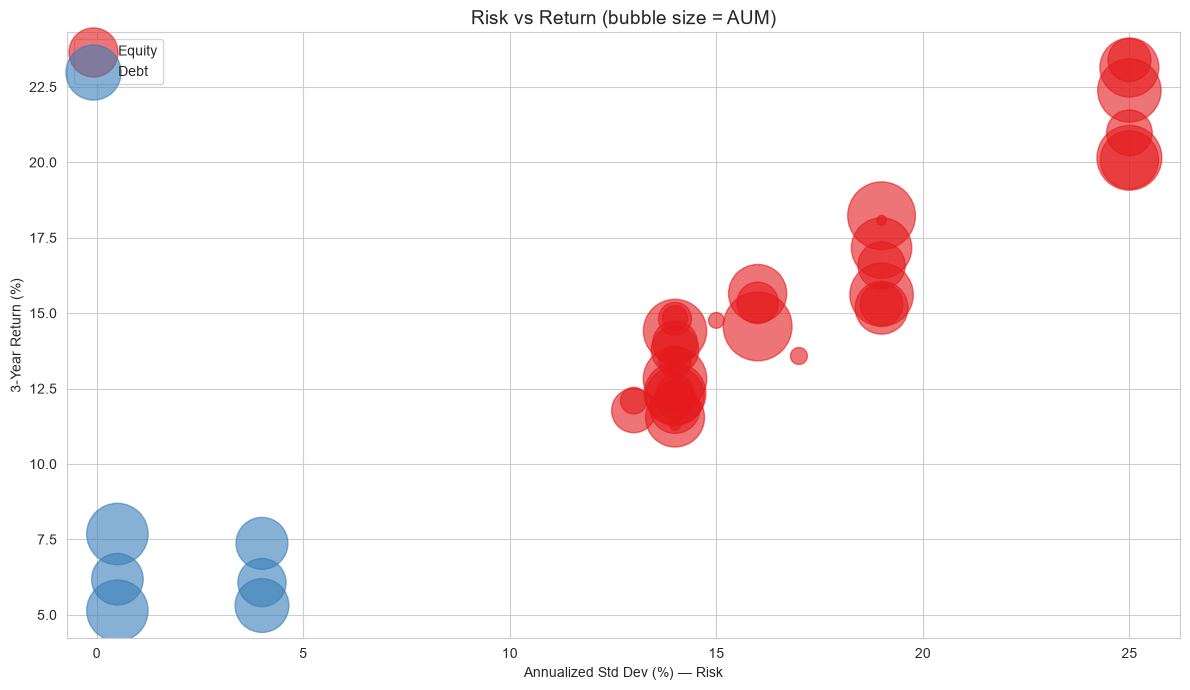

In [13]:
risk_return_query = '''
SELECT f.scheme_name, f.category, p.std_dev_ann_pct, p.return_3yr_pct, p.aum_crore
FROM fact_performance p
JOIN dim_fund f ON p.amfi_code = f.amfi_code
'''
rr_df = pd.read_sql(risk_return_query, engine)

fig, ax = plt.subplots(figsize=(12, 7))
categories = rr_df['category'].unique()
colors_map = dict(zip(categories, sns.color_palette('Set1', len(categories))))

for cat in categories:
    subset = rr_df[rr_df['category'] == cat]
    ax.scatter(subset['std_dev_ann_pct'], subset['return_3yr_pct'],
               s=subset['aum_crore']/20, alpha=0.6, label=cat, color=colors_map[cat])

ax.set_title('Risk vs Return (bubble size = AUM)', fontsize=14)
ax.set_xlabel('Annualized Std Dev (%) — Risk')
ax.set_ylabel('3-Year Return (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Transaction Type Breakdown

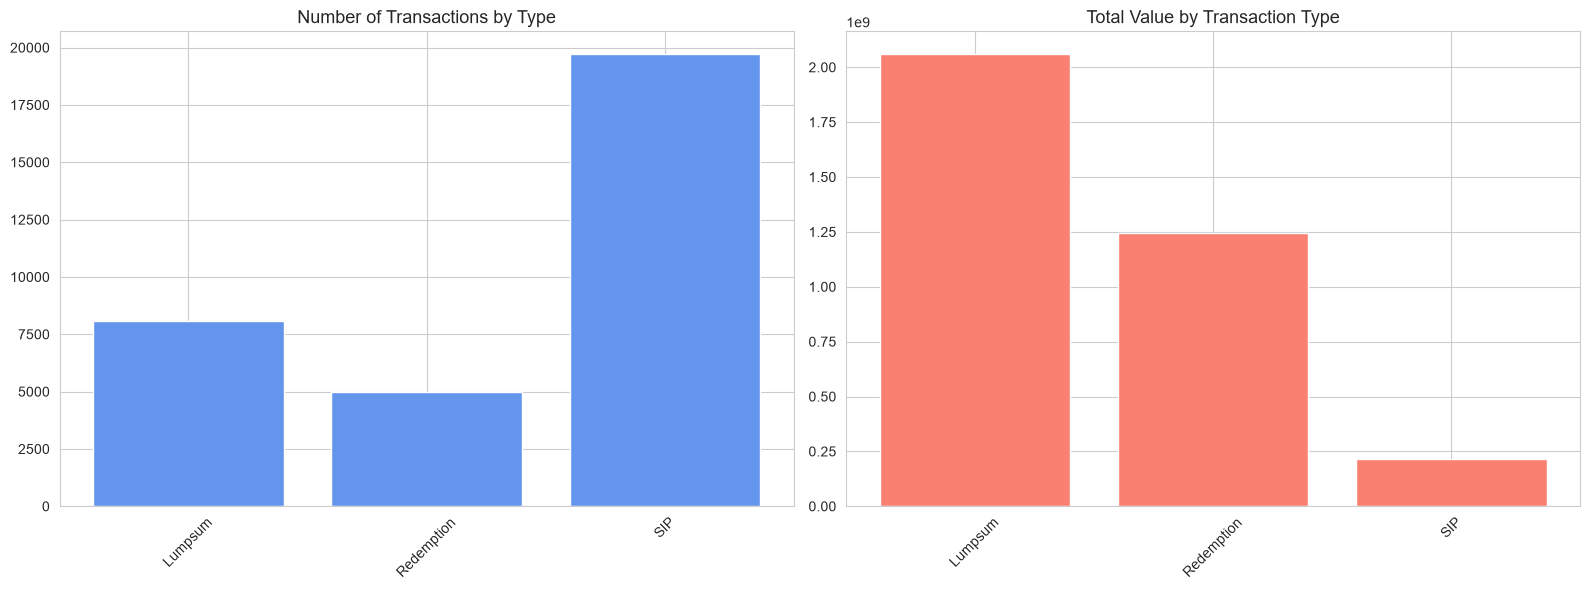

In [14]:
txn_type_query = '''
SELECT transaction_type, COUNT(*) AS num_txns, SUM(amount_inr) AS total_value
FROM fact_transactions
GROUP BY transaction_type
ORDER BY total_value DESC
'''
txn_type_df = pd.read_sql(txn_type_query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(txn_type_df['transaction_type'], txn_type_df['num_txns'], color='cornflowerblue')
axes[0].set_title('Number of Transactions by Type', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(txn_type_df['transaction_type'], txn_type_df['total_value'], color='salmon')
axes[1].set_title('Total Value by Transaction Type', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 13. Top 5 and Bottom 5 Performing Funds (3-Year Return)

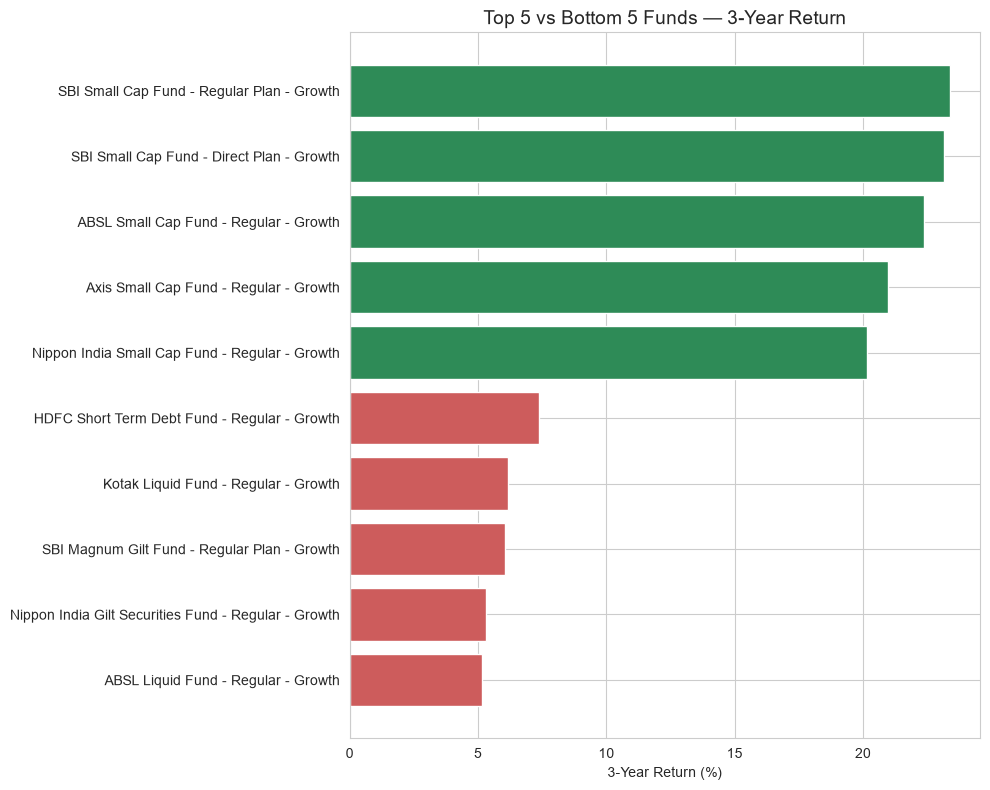

In [15]:
perf_query = '''
SELECT f.scheme_name, p.return_3yr_pct
FROM fact_performance p
JOIN dim_fund f ON p.amfi_code = f.amfi_code
ORDER BY p.return_3yr_pct DESC
'''
perf_df = pd.read_sql(perf_query, engine)
top5 = perf_df.head(5)
bottom5 = perf_df.tail(5)
combined = pd.concat([top5, bottom5])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['seagreen']*5 + ['indianred']*5
ax.barh(combined['scheme_name'][::-1], combined['return_3yr_pct'][::-1], color=colors[::-1])
ax.set_title('Top 5 vs Bottom 5 Funds — 3-Year Return', fontsize=14)
ax.set_xlabel('3-Year Return (%)')
plt.tight_layout()
plt.show()

## 14. NAV Volatility by Category

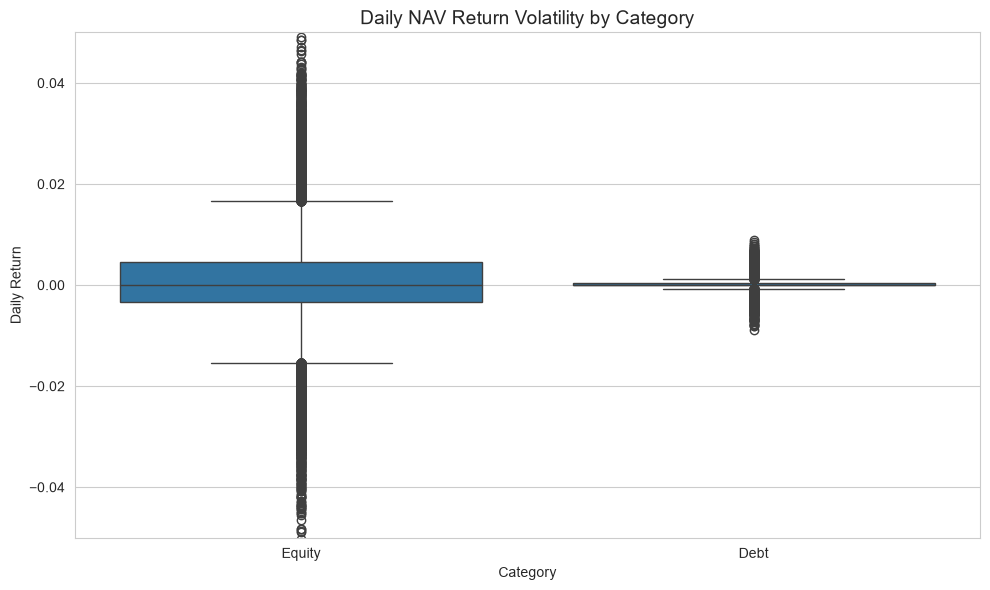

In [18]:
vol_query = '''
SELECT f.amfi_code, f.category, n.nav, d.date
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
JOIN dim_date d ON n.date_id = d.date_id
'''
vol_df = pd.read_sql(vol_query, engine)
vol_df['date'] = pd.to_datetime(vol_df['date'])

vol_df = vol_df.sort_values(['amfi_code', 'date'])
vol_df['daily_return'] = vol_df.groupby('amfi_code')['nav'].pct_change()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=vol_df.dropna(), x='category', y='daily_return', ax=ax)
ax.set_title('Daily NAV Return Volatility by Category', fontsize=14)
ax.set_xlabel('Category')
ax.set_ylabel('Daily Return')
ax.set_ylim(-0.05, 0.05)
plt.tight_layout()
plt.show()

## 15. Payment Mode & KYC Status Distribution

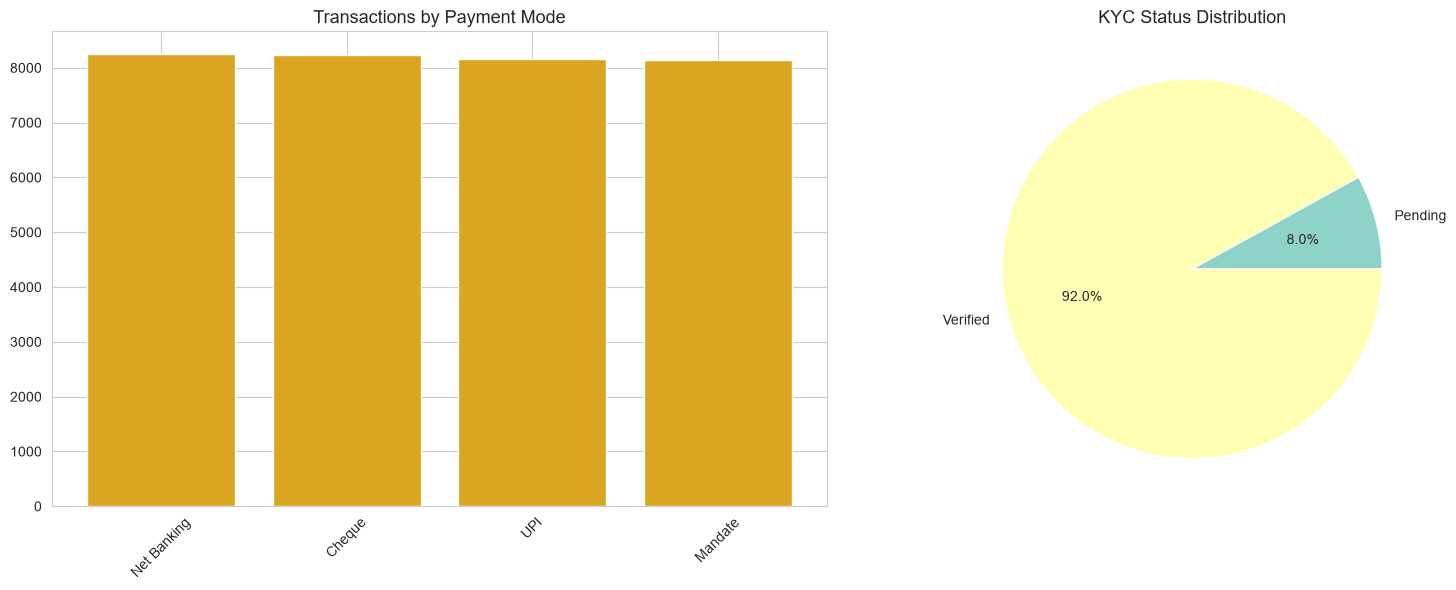

In [17]:
pay_query = '''
SELECT payment_mode, kyc_status, COUNT(*) AS num_txns
FROM fact_transactions
GROUP BY payment_mode, kyc_status
'''
pay_df = pd.read_sql(pay_query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

payment_totals = pay_df.groupby('payment_mode')['num_txns'].sum().sort_values(ascending=False)
axes[0].bar(payment_totals.index, payment_totals.values, color='goldenrod')
axes[0].set_title('Transactions by Payment Mode', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

kyc_totals = pay_df.groupby('kyc_status')['num_txns'].sum()
axes[1].pie(kyc_totals.values, labels=kyc_totals.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
axes[1].set_title('KYC Status Distribution', fontsize=13)

plt.tight_layout()
plt.show()

## Key Findings — Summary

1. **Equity outperforms Debt significantly**: Equity funds average ~15.5% returns across 1/3/5-year horizons, more than double Debt funds (~6-7%), consistent with the higher risk they carry.

2. **Risk and return are positively correlated**: The risk-return scatter shows a clear upward trend — funds with higher standard deviation (risk) generally deliver higher 3-year returns, particularly among Equity categories.

3. **Sharpe and Sortino ratios are nearly identical (r=0.99)**: This suggests downside risk closely tracks overall volatility in this fund universe, so either metric can be used interchangeably for risk-adjusted comparisons here.

4. **SIP inflows have grown steadily**: Industry-wide SIP inflow rose from ~₹11,500 Cr to ~₹31,000 Cr over the observed period, though YoY growth rate peaked around mid-2024 and has since cooled — signaling maturing, not slowing, adoption.

5. **SBI Mutual Fund leads AUM**: SBI holds the largest AUM among fund houses, followed by ICICI Prudential and HDFC — the top 3 houses account for a disproportionate share of industry assets.

6. **Small Cap funds dominate top performers**: All 5 top-performing funds by 3-year return are Small Cap equity funds, while the bottom 5 are Debt/Gilt/Liquid funds — reinforcing the risk-return tradeoff.

7. **SIP transactions are most frequent, but Lumpsum moves more money**: SIP accounts for the highest transaction count, but Lumpsum investments contribute the largest total transaction value — investors use SIP for regular contributions and lumpsum for bigger, one-off allocations.

8. **Debt funds have both lower returns and lower expense ratios**: Debt fund expense ratios cluster around 0.6-0.8%, roughly half of Equity funds (1.4-1.6%), reflecting lower active management costs.

9. **KYC compliance is high but not universal**: 92% of transactions come from KYC-verified investors, leaving an 8% pending segment that represents a potential compliance/onboarding gap.

10. **Investor base skews younger and male**: The 26-35 age group drives the highest transaction volume, and male investors account for 66.5% of transactions — highlighting a demographic segment for potential financial-inclusion outreach.